In [1]:
#Setup and Installation
!pip -q install scikit-image

import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, Input, Model
from tensorflow.keras import backend as K
from skimage.metrics import structural_similarity as ssim_fn

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


1. Load and Preprocess MNIST

In [2]:

(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

N_TRAIN, N_TEST = 10000, 2000
rng = np.random.RandomState(SEED)

train_idx = rng.permutation(len(x_train_full))[:N_TRAIN]
test_idx = rng.permutation(len(x_test_full))[:N_TEST]

x_train = x_train_full[train_idx].astype("float32") / 255.0
y_train = y_train_full[train_idx]
x_test = x_test_full[test_idx].astype("float32") / 255.0
y_test = y_test_full[test_idx]

# Channel dimension for conv models
x_train_c = x_train[..., np.newaxis]  # (N, 28, 28, 1)
x_test_c = x_test[..., np.newaxis]

# Flattened version for the fully connected AE
x_train_f = x_train.reshape(-1, 784)
x_test_f = x_test.reshape(-1, 784)

print("x_train:", x_train_c.shape, " x_test:", x_test_c.shape)
print("x_train flattened:", x_train_f.shape, " x_test flattened:", x_test_f.shape)
print("Pixel range:", x_train.min(), "-", x_train.max())


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train: (10000, 28, 28, 1)  x_test: (2000, 28, 28, 1)
x_train flattened: (10000, 784)  x_test flattened: (2000, 784)
Pixel range: 0.0 - 1.0


2. Fully connected autoencoder (build)

In [3]:

LATENT_DIM_FC = 16

def build_fc_autoencoder(latent_dim=LATENT_DIM_FC):
    inp = Input(shape=(784,))
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dense(32, activation="relu")(x)
    z = layers.Dense(latent_dim, activation="relu", name="latent")(x)
    x = layers.Dense(32, activation="relu")(z)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(784, activation="sigmoid")(x)

    autoencoder = Model(inp, out, name="fc_autoencoder")
    encoder = Model(inp, z, name="fc_encoder")
    autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
    return autoencoder, encoder

fc_ae, fc_encoder = build_fc_autoencoder()
fc_ae.summary()


Model: "fc_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

3. Fully Connected Autoencoder - Train

In [4]:

EPOCHS_FC = 20
BATCH_SIZE = 128

start = time.time()
fc_history = fc_ae.fit(x_train_f, x_train_f, validation_data=(x_test_f, x_test_f),
                        epochs=EPOCHS_FC, batch_size=BATCH_SIZE, verbose=1)
fc_train_time = time.time() - start
print(f"FC-AE training time: {fc_train_time:.2f} s")


Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.3447 - val_loss: 0.2450
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2279 - val_loss: 0.2075
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1937 - val_loss: 0.1798
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1746 - val_loss: 0.1674
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1636 - val_loss: 0.1588
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1557 - val_loss: 0.1514
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1492 - val_loss: 0.1460
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1440 - val_loss: 0.1416
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1406 - val_loss: 0.1393
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1382 - val_loss: 0.1376
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1364 - val_loss: 0.1366
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1347 - val_l

4. Plot 1 — Original vs. Reconstructed Images (FC-AE)

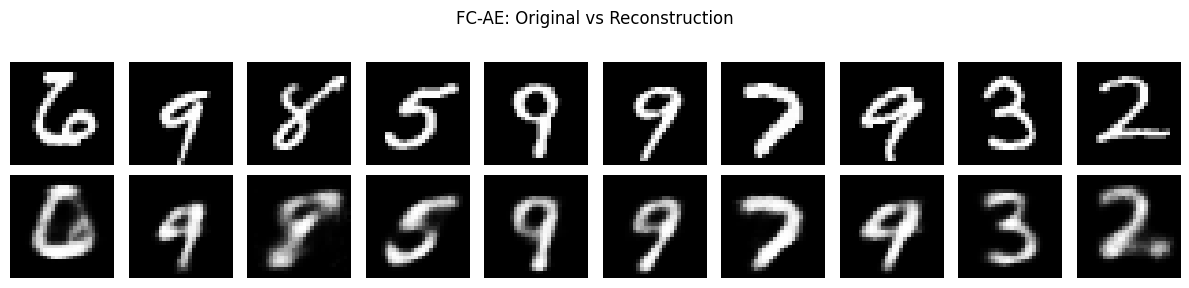

In [5]:

def plot_original_vs_reconstructed(originals, reconstructions, n=10, title="Original vs Reconstruction"):
    fig, axes = plt.subplots(2, n, figsize=(n * 1.2, 3))
    for i in range(n):
        axes[0, i].imshow(originals[i].reshape(28, 28), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(reconstructions[i].reshape(28, 28), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Original", fontsize=10)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=10)
    fig.suptitle(title)
    plt.tight_layout()
    return fig

fc_recon = fc_ae.predict(x_test_f[:10], verbose=0)
fig = plot_original_vs_reconstructed(x_test_f[:10], fc_recon, n=10, title="FC-AE: Original vs Reconstruction")
plt.savefig("plot1_fc_original_vs_recon.png", dpi=150)
plt.show()


5. Plot 2 — FC-AE Training and Validation Loss

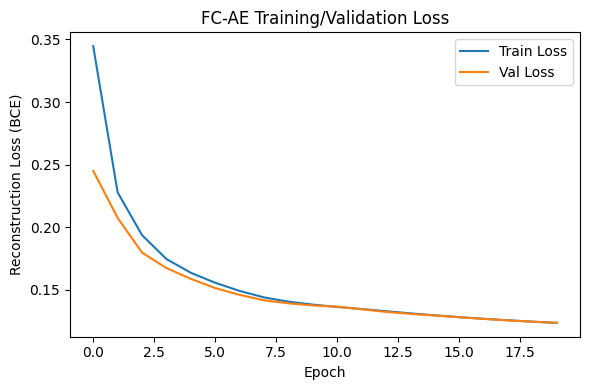

In [6]:

plt.figure(figsize=(6, 4))
plt.plot(fc_history.history["loss"], label="Train Loss")
plt.plot(fc_history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Reconstruction Loss (BCE)")
plt.title("FC-AE Training/Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("plot2_fc_loss_curve.png", dpi=150)
plt.show()


6. Reconstruction Metrics (MSE, MAE, SSIM)

In [7]:

def compute_metrics(originals, reconstructions):
    # originals, reconstructions: (N, 28, 28) or (N, 784) in [0,1]
    o = originals.reshape(-1, 28, 28)
    r = reconstructions.reshape(-1, 28, 28)
    mse = np.mean((o - r) ** 2)
    mae = np.mean(np.abs(o - r))
    ssim_vals = [ssim_fn(o[i], r[i], data_range=1.0) for i in range(len(o))]
    mean_ssim = np.mean(ssim_vals)
    return mse, mae, mean_ssim, np.array(ssim_vals)

fc_test_recon = fc_ae.predict(x_test_f, verbose=0)
fc_mse, fc_mae, fc_ssim, fc_ssim_all = compute_metrics(x_test_f, fc_test_recon)

print("Fully Connected Autoencoder — Test Set Metrics")
print(f"Test MSE  : {fc_mse:.6f}")
print(f"Test MAE  : {fc_mae:.6f}")
print(f"Mean SSIM : {fc_ssim:.4f}")


Fully Connected Autoencoder — Test Set Metrics
Test MSE  : 0.020223
Test MAE  : 0.055450
Mean SSIM : 0.7682


7. Convolutional Autoencoder — Build

In [8]:

def build_conv_autoencoder():
    inp = Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D(2, padding="same", name="latent_feature_map")(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    autoencoder = Model(inp, out, name="conv_autoencoder")
    encoder = Model(inp, encoded, name="conv_encoder")
    autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
    return autoencoder, encoder

conv_ae, conv_encoder = build_conv_autoencoder()
conv_ae.summary()


Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_feature_map              │ (None, 7, 7, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

8. Convolutional Autoencoder — Train

In [9]:

start = time.time()
conv_history = conv_ae.fit(x_train_c, x_train_c, validation_data=(x_test_c, x_test_c),
                            epochs=EPOCHS_FC, batch_size=BATCH_SIZE, verbose=1)
conv_train_time = time.time() - start
print(f"Conv-AE training time: {conv_train_time:.2f} s")


Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - loss: 0.2433 - val_loss: 0.1041
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0931 - val_loss: 0.0858
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0837 - val_loss: 0.0809
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0794 - val_loss: 0.0770
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0770 - val_loss: 0.0760
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0751 - val_loss: 0.0743
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0738 - val_loss: 0.0743
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0729 - val_loss: 0.0735
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0722 - val_loss: 0.0726
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0716 - val_loss: 0.0719
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0710 - val_loss: 0.0710
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0705 - val_

9. Comparing Fully Connected and Convolutional Autoencoders

                         MSE       MAE      SSIM  Parameters
Fully Connected AE  0.020223  0.055450  0.768204    211040.0
Convolutional AE    0.002522  0.015225  0.973861     74497.0


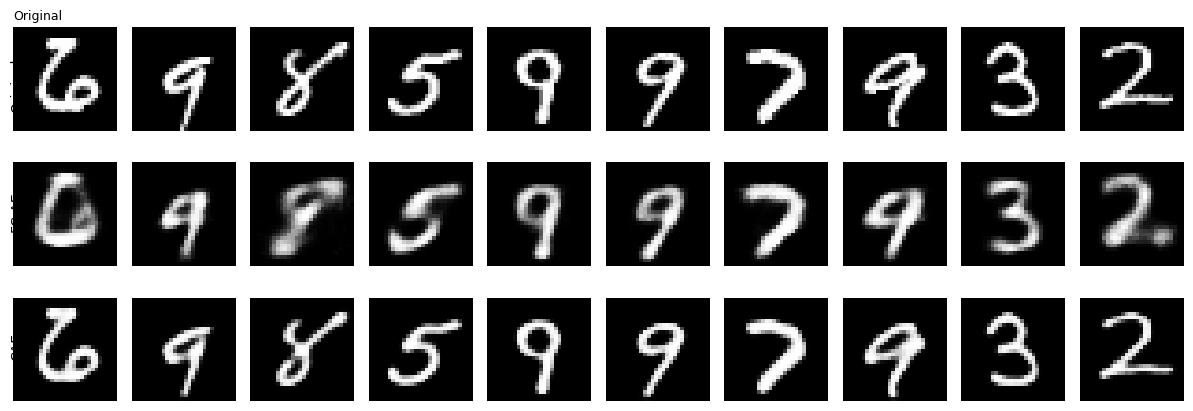

In [10]:

conv_test_recon = conv_ae.predict(x_test_c, verbose=0)
conv_mse, conv_mae, conv_ssim, conv_ssim_all = compute_metrics(x_test_c, conv_test_recon)

comparison_fc_conv = pd.DataFrame({
    "Fully Connected AE": {"MSE": fc_mse, "MAE": fc_mae, "SSIM": fc_ssim, "Parameters": fc_ae.count_params()},
    "Convolutional AE": {"MSE": conv_mse, "MAE": conv_mae, "SSIM": conv_ssim, "Parameters": conv_ae.count_params()},
}).T
print(comparison_fc_conv)

# Plot 3: Original -> FC-AE Reconstruction -> CAE Reconstruction
n = 10
fig, axes = plt.subplots(3, n, figsize=(n * 1.2, 4.5))
for i in range(n):
    axes[0, i].imshow(x_test[i], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(fc_test_recon[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(conv_test_recon[i].reshape(28, 28), cmap="gray"); axes[2, i].axis("off")
axes[0, 0].set_title("Original", loc="left", fontsize=9)
fig.text(0.01, 0.78, "Original", va="center", rotation=90, fontsize=10)
fig.text(0.01, 0.5, "FC-AE", va="center", rotation=90, fontsize=10)
fig.text(0.01, 0.2, "CAE", va="center", rotation=90, fontsize=10)
plt.tight_layout()
plt.savefig("plot3_fc_vs_cae_reconstruction.png", dpi=150)
plt.show()


10. Adding Image Noise (Gaussian and Salt-and-Pepper)

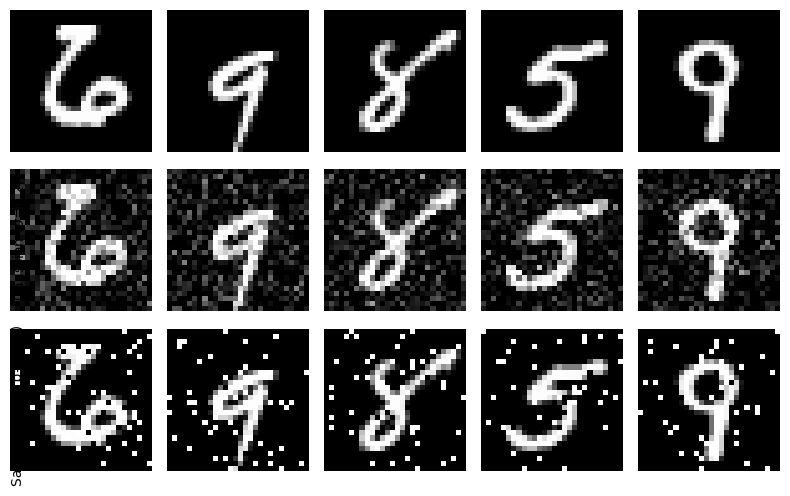

In [11]:

def add_gaussian_noise(images, sigma):
    noisy = images + np.random.normal(0, sigma, images.shape).astype("float32")
    return np.clip(noisy, 0.0, 1.0)

def add_salt_pepper_noise(images, p):
    noisy = images.copy()
    mask = np.random.rand(*images.shape)
    noisy[mask < p / 2] = 0.0
    noisy[(mask >= p / 2) & (mask < p)] = 1.0
    return noisy

# Visualize both corruption types on a few samples
sample_imgs = x_test_c[:5]
gauss_example = add_gaussian_noise(sample_imgs, sigma=0.2)
sp_example = add_salt_pepper_noise(sample_imgs, p=0.10)

fig, axes = plt.subplots(3, 5, figsize=(8, 5))
for i in range(5):
    axes[0, i].imshow(sample_imgs[i, :, :, 0], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(gauss_example[i, :, :, 0], cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(sp_example[i, :, :, 0], cmap="gray"); axes[2, i].axis("off")
fig.text(0.02, 0.83, "Clean", va="center", rotation=90)
fig.text(0.02, 0.5, "Gaussian ($\\sigma$=0.2)", va="center", rotation=90)
fig.text(0.02, 0.17, "Salt & Pepper (p=0.10)", va="center", rotation=90)
plt.tight_layout()
plt.savefig("noise_types_example.png", dpi=150)
plt.show()


11. Denoising Convolutional Autoencoder — Build and Train

In [12]:

NOISE_SIGMA_TRAIN = 0.2

x_train_noisy = add_gaussian_noise(x_train_c, sigma=NOISE_SIGMA_TRAIN)
x_test_noisy = add_gaussian_noise(x_test_c, sigma=NOISE_SIGMA_TRAIN)

denoise_ae, denoise_encoder = build_conv_autoencoder()

start = time.time()
denoise_history = denoise_ae.fit(
    x_train_noisy, x_train_c,  # noisy input, clean target
    validation_data=(x_test_noisy, x_test_c),
    epochs=EPOCHS_FC, batch_size=BATCH_SIZE, verbose=1
)
denoise_train_time = time.time() - start
print(f"Denoising CAE training time: {denoise_train_time:.2f} s")


Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - loss: 0.2495 - val_loss: 0.1239
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1082 - val_loss: 0.0976
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0948 - val_loss: 0.0903
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0893 - val_loss: 0.0867
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0863 - val_loss: 0.0843
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0841 - val_loss: 0.0824
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0825 - val_loss: 0.0811
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0813 - val_loss: 0.0801
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0804 - val_loss: 0.0794
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0796 - val_loss: 0.0788
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0790 - val_loss: 0.0782
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0785 - val_l

12. Plot 4 — Clean vs. Noisy vs. Denoised

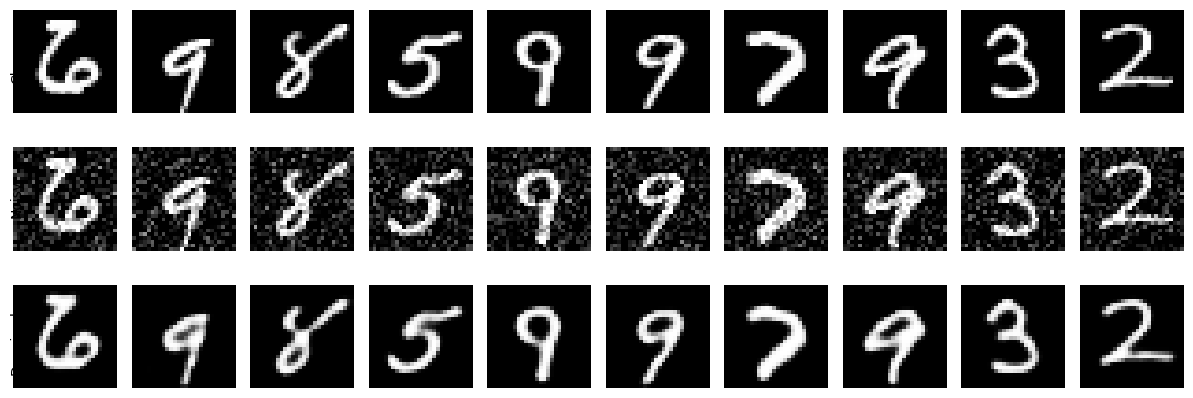

In [13]:

denoised_test = denoise_ae.predict(x_test_noisy[:10], verbose=0)

n = 10
fig, axes = plt.subplots(3, n, figsize=(n * 1.2, 4.5))
for i in range(n):
    axes[0, i].imshow(x_test_c[i, :, :, 0], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(x_test_noisy[i, :, :, 0], cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(denoised_test[i, :, :, 0], cmap="gray"); axes[2, i].axis("off")
fig.text(0.01, 0.8, "Clean", va="center", rotation=90)
fig.text(0.01, 0.5, "Noisy", va="center", rotation=90)
fig.text(0.01, 0.18, "Denoised", va="center", rotation=90)
plt.tight_layout()
plt.savefig("plot4_clean_noisy_denoised.png", dpi=150)
plt.show()


13. Plot 5 — Noise Level vs. Reconstruction Quality

sigma=0.1: MSE=0.003705  MAE=0.018036  SSIM=0.9613
sigma=0.2: MSE=0.004630  MAE=0.021213  SSIM=0.9480
sigma=0.3: MSE=0.007031  MAE=0.029196  SSIM=0.8791

                   MSE       MAE      SSIM
Noise Level                              
0.1          0.003705  0.018036  0.961281
0.2          0.004630  0.021213  0.947962
0.3          0.007031  0.029196  0.879089


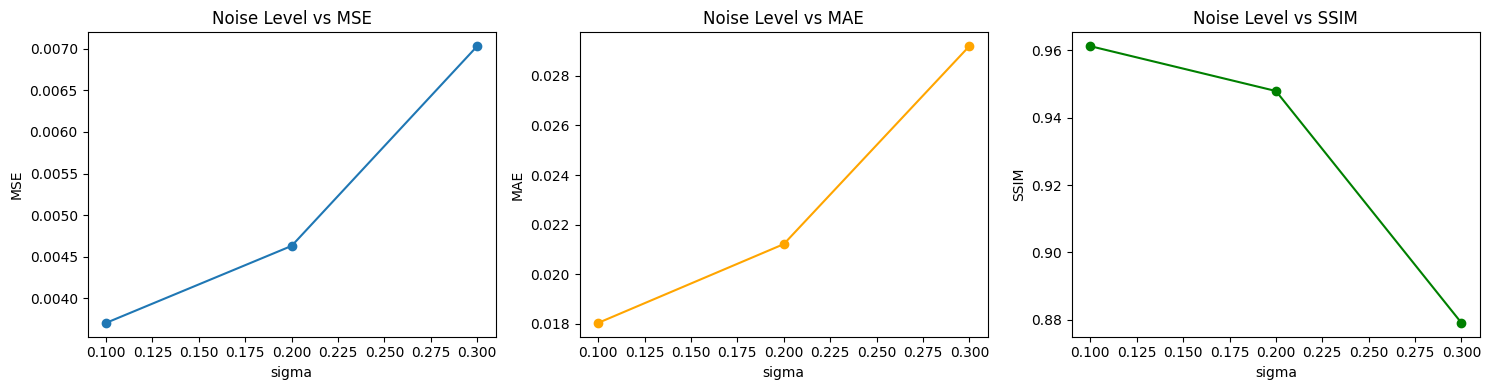

In [14]:

noise_levels = [0.1, 0.2, 0.3]
noise_results = []

for sigma in noise_levels:
    x_test_noisy_s = add_gaussian_noise(x_test_c, sigma=sigma)
    denoised_s = denoise_ae.predict(x_test_noisy_s, verbose=0)
    mse_s, mae_s, ssim_s, _ = compute_metrics(x_test_c, denoised_s)
    noise_results.append({"Noise Level": sigma, "MSE": mse_s, "MAE": mae_s, "SSIM": ssim_s})
    print(f"sigma={sigma}: MSE={mse_s:.6f}  MAE={mae_s:.6f}  SSIM={ssim_s:.4f}")

noise_df = pd.DataFrame(noise_results).set_index("Noise Level")
print("\n", noise_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(noise_df.index, noise_df["MSE"], marker="o"); axes[0].set_title("Noise Level vs MSE"); axes[0].set_xlabel("sigma"); axes[0].set_ylabel("MSE")
axes[1].plot(noise_df.index, noise_df["MAE"], marker="o", color="orange"); axes[1].set_title("Noise Level vs MAE"); axes[1].set_xlabel("sigma"); axes[1].set_ylabel("MAE")
axes[2].plot(noise_df.index, noise_df["SSIM"], marker="o", color="green"); axes[2].set_title("Noise Level vs SSIM"); axes[2].set_xlabel("sigma"); axes[2].set_ylabel("SSIM")
plt.tight_layout()
plt.savefig("plot5_noise_level_vs_quality.png", dpi=150)
plt.show()


14. Variational Autoencoder (VAE) — Build

In [16]:
LATENT_DIM_VAE = 2

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Encoder
vae_inp = Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(vae_inp)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
conv_shape_before_flatten = x.shape[1:]
x = layers.Flatten()(x)
x = layers.Dense(32, activation="relu")(x)
z_mean = layers.Dense(LATENT_DIM_VAE, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM_VAE, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
vae_encoder = Model(vae_inp, [z_mean, z_log_var, z], name="vae_encoder")
vae_encoder.summary()

# Decoder
latent_inp = Input(shape=(LATENT_DIM_VAE,))
x = layers.Dense(int(np.prod(conv_shape_before_flatten)), activation="relu")(latent_inp)
x = layers.Reshape(conv_shape_before_flatten)(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
vae_out = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
vae_decoder = Model(latent_inp, vae_out, name="vae_decoder")
vae_decoder.summary()

class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = recon_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │    100,384 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         66 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         66 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 119,332 (466.14 KB)

 Trainable params: 119,332 (466.14 KB)

 Non-trainable params: 0 (0.00 B)

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

15. VAE — Train

In [17]:

EPOCHS_VAE = 30

start = time.time()
vae_history = vae.fit(x_train_c, x_train_c, validation_data=(x_test_c, x_test_c),
                       epochs=EPOCHS_VAE, batch_size=BATCH_SIZE, verbose=1)
vae_train_time = time.time() - start
print(f"VAE training time: {vae_train_time:.2f} s")


Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - kl_loss: 3.2988 - loss: 290.7076 - recon_loss: 287.4088 - val_kl_loss: 3.1510 - val_loss: 210.6479 - val_recon_loss: 207.4969
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 3.3168 - loss: 204.9183 - recon_loss: 201.6015 - val_kl_loss: 3.3237 - val_loss: 201.0636 - val_recon_loss: 197.7399
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 3.7952 - loss: 197.5481 - recon_loss: 193.7529 - val_kl_loss: 5.1907 - val_loss: 192.5982 - val_recon_loss: 187.4075
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 5.3454 - loss: 187.8295 - recon_loss: 182.4841 - val_kl_loss: 5.3952 - val_loss: 184.2985 - val_recon_loss: 178.9033
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 5.6222 - loss: 181.3002 - recon_loss: 175.6779 - val_kl_loss: 5.3801 - val_loss: 178.7341 - val_recon_loss: 173.3540
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 5.5937 - loss: 176.9691 - recon_loss: 171.3754 

16. VAE Training/Validation Loss Curve

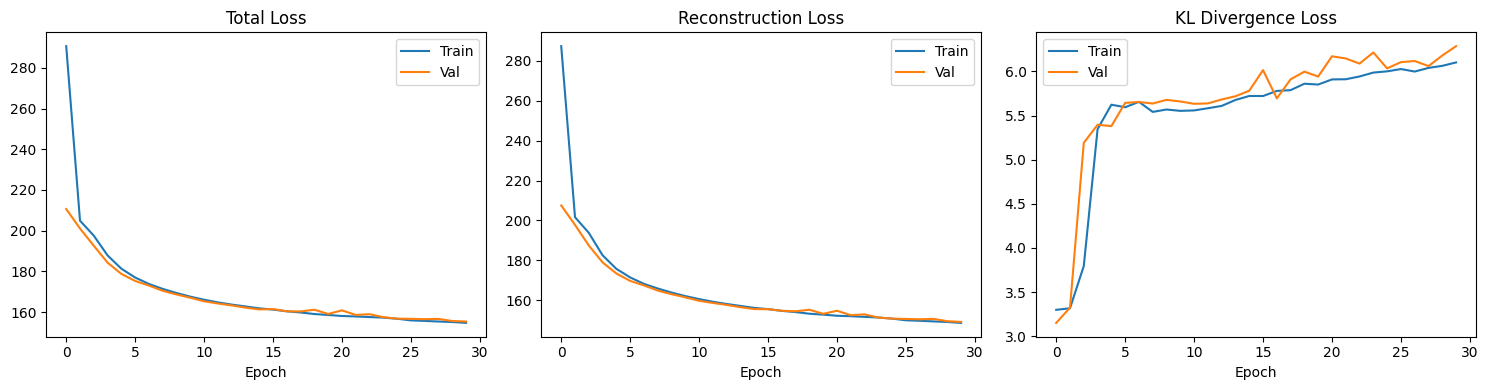

Final VAE — Train total: 154.66  Val total: 155.34  Train recon: 148.56  Train KL: 6.10


In [18]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(vae_history.history["loss"], label="Train"); axes[0].plot(vae_history.history["val_loss"], label="Val")
axes[0].set_title("Total Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(vae_history.history["recon_loss"], label="Train"); axes[1].plot(vae_history.history["val_recon_loss"], label="Val")
axes[1].set_title("Reconstruction Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
axes[2].plot(vae_history.history["kl_loss"], label="Train"); axes[2].plot(vae_history.history["val_kl_loss"], label="Val")
axes[2].set_title("KL Divergence Loss"); axes[2].set_xlabel("Epoch"); axes[2].legend()
plt.tight_layout()
plt.savefig("plot9_vae_loss_curve.png", dpi=150)
plt.show()

print(f"Final VAE — Train total: {vae_history.history['loss'][-1]:.2f}  "
      f"Val total: {vae_history.history['val_loss'][-1]:.2f}  "
      f"Train recon: {vae_history.history['recon_loss'][-1]:.2f}  "
      f"Train KL: {vae_history.history['kl_loss'][-1]:.2f}")


17. Plot 6 — VAE Latent Space Visualization

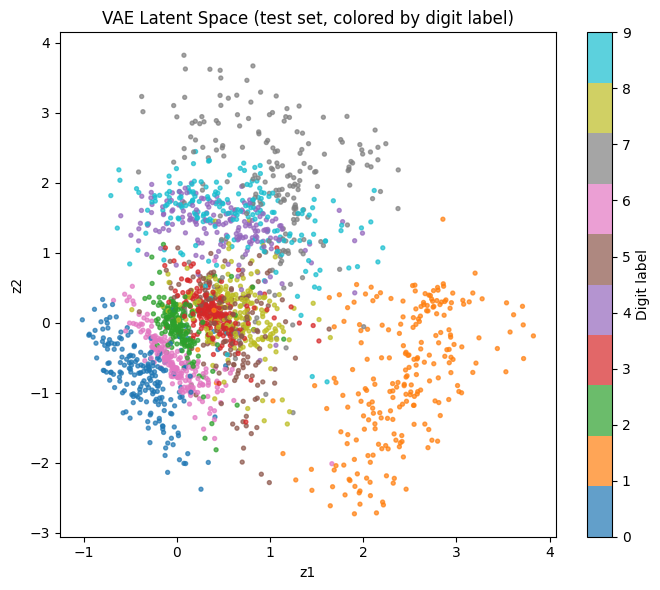

In [19]:

z_mean_test, _, _ = vae_encoder.predict(x_test_c, verbose=0)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(z_mean_test[:, 0], z_mean_test[:, 1], c=y_test, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, label="Digit label")
plt.xlabel("z1"); plt.ylabel("z2")
plt.title("VAE Latent Space (test set, colored by digit label)")
plt.tight_layout()
plt.savefig("plot6_vae_latent_space.png", dpi=150)
plt.show()


18. Plot 7 — Randomly Generated VAE Images

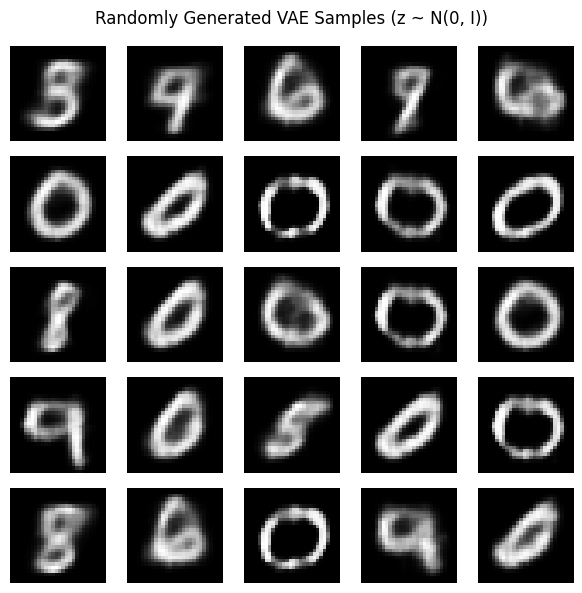

In [20]:

N_GEN = 25
rng_gen = np.random.RandomState(SEED)
random_latents = rng_gen.normal(size=(N_GEN, LATENT_DIM_VAE)).astype("float32")
generated_imgs = vae_decoder.predict(random_latents, verbose=0)

grid_size = 5
fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_imgs[i, :, :, 0], cmap="gray")
    ax.axis("off")
plt.suptitle("Randomly Generated VAE Samples (z ~ N(0, I))")
plt.tight_layout()
plt.savefig("plot7_vae_generated_samples.png", dpi=150)
plt.show()


19. Plot 8 — Latent Space Interpolation

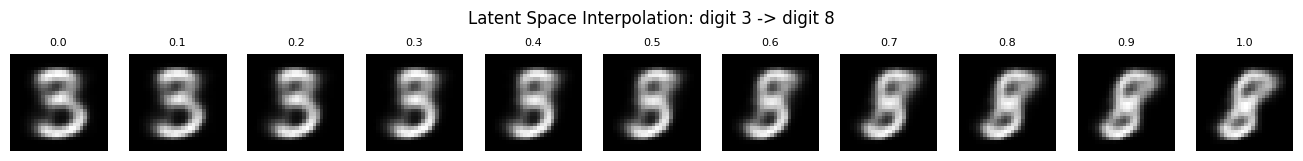

In [21]:

# Pick two test images from different digit classes for interpolation
idx_a = np.where(y_test == 3)[0][0]
idx_b = np.where(y_test == 8)[0][0]

z_a, _, _ = vae_encoder.predict(x_test_c[idx_a:idx_a+1], verbose=0)
z_b, _, _ = vae_encoder.predict(x_test_c[idx_b:idx_b+1], verbose=0)

alphas = np.arange(0, 1.01, 0.1)
z_interp = np.array([(1 - a) * z_a[0] + a * z_b[0] for a in alphas])
decoded_interp = vae_decoder.predict(z_interp, verbose=0)

fig, axes = plt.subplots(1, len(alphas), figsize=(len(alphas) * 1.2, 1.6))
for i, ax in enumerate(axes):
    ax.imshow(decoded_interp[i, :, :, 0], cmap="gray")
    ax.set_title(f"{alphas[i]:.1f}", fontsize=8)
    ax.axis("off")
plt.suptitle(f"Latent Space Interpolation: digit {y_test[idx_a]} -> digit {y_test[idx_b]}")
plt.tight_layout()
plt.savefig("plot8_vae_interpolation.png", dpi=150)
plt.show()


20. Reconstruction Comparison Across Models

In [23]:
_, _, z_test = vae_encoder.predict(x_test_c, verbose=0)
vae_recon_test = vae_decoder.predict(z_test, verbose=0)
vae_mse, vae_mae, vae_ssim, vae_ssim_all = compute_metrics(x_test_c, vae_recon_test)

denoised_full = denoise_ae.predict(x_test_noisy, verbose=0)
denoise_mse, denoise_mae, denoise_ssim, denoise_ssim_all = compute_metrics(x_test_c, denoised_full)

recon_comparison = pd.DataFrame({
    "Fully Connected AE": {"MSE": fc_mse, "MAE": fc_mae, "SSIM": fc_ssim, "Parameters": fc_ae.count_params()},
    "Convolutional AE": {"MSE": conv_mse, "MAE": conv_mae, "SSIM": conv_ssim, "Parameters": conv_ae.count_params()},
    "Denoising CAE": {"MSE": denoise_mse, "MAE": denoise_mae, "SSIM": denoise_ssim, "Parameters": denoise_ae.count_params()},
}).T
print("Reconstruction-based models:\n", recon_comparison)

vae_metrics = pd.DataFrame({
    "VAE Metric": ["Reconstruction Loss", "KL Loss", "Total Loss", "Test MSE", "Test MAE", "Mean SSIM"],
    "Value": [vae_history.history["val_recon_loss"][-1], vae_history.history["val_kl_loss"][-1],
              vae_history.history["val_loss"][-1], vae_mse, vae_mae, vae_ssim]
})
print("\nVAE (reported separately due to KL term):\n", vae_metrics)


Reconstruction-based models:
                          MSE       MAE      SSIM  Parameters
Fully Connected AE  0.020223  0.055450  0.768204    211040.0
Convolutional AE    0.002522  0.015225  0.973861     74497.0
Denoising CAE       0.004652  0.021279  0.947733     74497.0

VAE (reported separately due to KL term):
             VAE Metric       Value
0  Reconstruction Loss  149.052155
1              KL Loss    6.285384
2           Total Loss  155.337524
3             Test MSE    0.043453
4             Test MAE    0.101844
5            Mean SSIM    0.517739


21. Plot 9 — Reconstruction Error Distribution (Test Set)

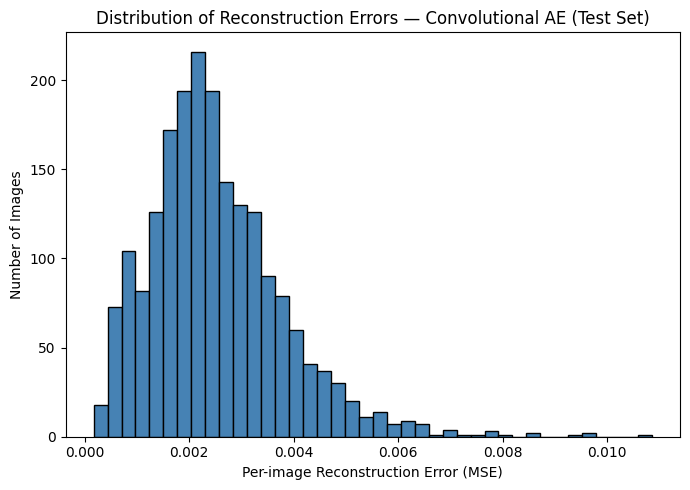

Error range: [0.000170, 0.010863]
Mean: 0.002522  Median: 0.002334  Std: 0.001293


In [24]:

# Using the Convolutional Autoencoder as the reference reconstruction-based model
per_image_error = np.mean((x_test_c.reshape(-1, 784) - conv_test_recon.reshape(-1, 784)) ** 2, axis=1)

plt.figure(figsize=(7, 5))
plt.hist(per_image_error, bins=40, color="steelblue", edgecolor="black")
plt.xlabel("Per-image Reconstruction Error (MSE)")
plt.ylabel("Number of Images")
plt.title("Distribution of Reconstruction Errors — Convolutional AE (Test Set)")
plt.tight_layout()
plt.savefig("plot10_reconstruction_error_distribution.png", dpi=150)
plt.show()

print(f"Error range: [{per_image_error.min():.6f}, {per_image_error.max():.6f}]")
print(f"Mean: {per_image_error.mean():.6f}  Median: {np.median(per_image_error):.6f}  Std: {per_image_error.std():.6f}")


22. Required High-Error Image Analysis (Top-5)

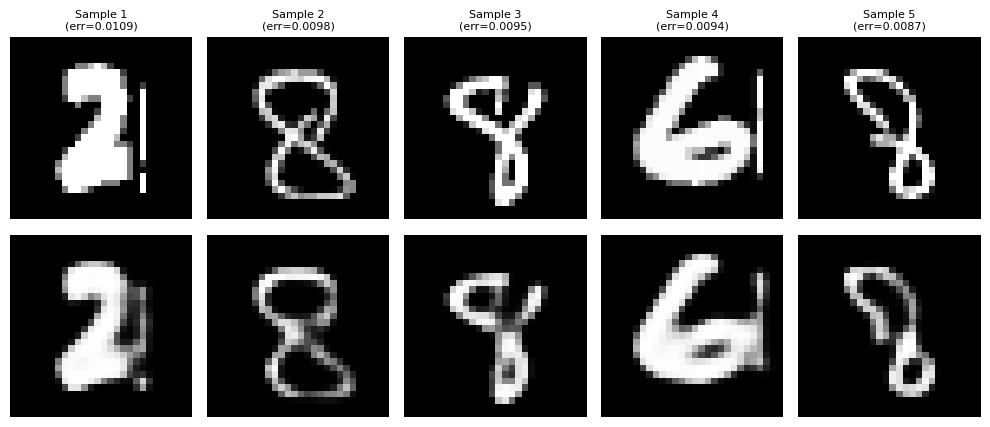

Sample 1: test index=1670, true label=2, error=0.010863
Sample 2: test index=262, true label=8, error=0.009761
Sample 3: test index=417, true label=8, error=0.009534
Sample 4: test index=97, true label=6, error=0.009394
Sample 5: test index=1893, true label=8, error=0.008697


In [25]:

top5_idx = np.argsort(per_image_error)[-5:][::-1]

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for col, idx in enumerate(top5_idx):
    axes[0, col].imshow(x_test_c[idx, :, :, 0], cmap="gray"); axes[0, col].axis("off")
    axes[0, col].set_title(f"Sample {col+1}\n(err={per_image_error[idx]:.4f})", fontsize=8)
    axes[1, col].imshow(conv_test_recon[idx, :, :, 0], cmap="gray"); axes[1, col].axis("off")
fig.text(0.02, 0.75, "Original", va="center", rotation=90)
fig.text(0.02, 0.3, "Reconstruction", va="center", rotation=90)
plt.tight_layout()
plt.savefig("high_error_samples.png", dpi=150)
plt.show()

for col, idx in enumerate(top5_idx):
    print(f"Sample {col+1}: test index={idx}, true label={y_test[idx]}, error={per_image_error[idx]:.6f}")


23. Consolidated Results

In [26]:

consolidated = pd.DataFrame({
    "FC Autoencoder": {"MSE": fc_mse, "MAE": fc_mae, "SSIM": fc_ssim,
                        "Parameters": fc_ae.count_params(), "Time (s)": fc_train_time},
    "Conv. Autoencoder": {"MSE": conv_mse, "MAE": conv_mae, "SSIM": conv_ssim,
                           "Parameters": conv_ae.count_params(), "Time (s)": conv_train_time},
    "Denoising CAE": {"MSE": denoise_mse, "MAE": denoise_mae, "SSIM": denoise_ssim,
                       "Parameters": denoise_ae.count_params(), "Time (s)": denoise_train_time},
    "VAE": {"MSE": vae_mse, "MAE": vae_mae, "SSIM": vae_ssim,
            "Parameters": vae.encoder.count_params() + vae.decoder.count_params(), "Time (s)": vae_train_time},
}).T
print(consolidated)


                        MSE       MAE      SSIM  Parameters   Time (s)
FC Autoencoder     0.020223  0.055450  0.768204    211040.0  12.664518
Conv. Autoencoder  0.002522  0.015225  0.973861     74497.0  22.937352
Denoising CAE      0.004652  0.021279  0.947733     74497.0  22.906416
VAE                0.043453  0.101844  0.517739    184421.0  32.551570


24. Additional Latent-Dimension Study

dz=  2  MSE=0.051675  SSIM=0.4158  Params=210130
dz=  8  MSE=0.033341  SSIM=0.6413  Params=210520
dz= 16  MSE=0.024790  SSIM=0.7164  Params=211040
dz= 32  MSE=0.021358  SSIM=0.7564  Params=212080

                        MSE      SSIM  Parameters
Latent Dimension                                
2                 0.051675  0.415794      210130
8                 0.033341  0.641284      210520
16                0.024790  0.716446      211040
32                0.021358  0.756418      212080


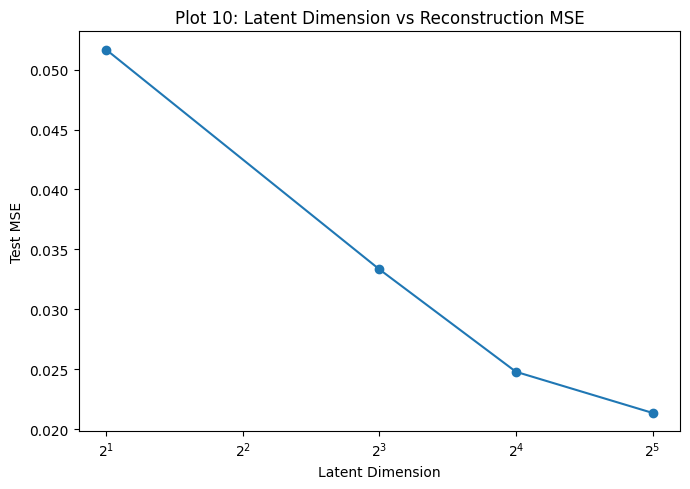

In [27]:

latent_dims = [2, 8, 16, 32]
latent_study_results = []

for dz in latent_dims:
    ae, enc = build_fc_autoencoder(latent_dim=dz)
    ae.fit(x_train_f, x_train_f, validation_data=(x_test_f, x_test_f),
           epochs=15, batch_size=BATCH_SIZE, verbose=0)
    recon = ae.predict(x_test_f, verbose=0)
    mse_dz, mae_dz, ssim_dz, _ = compute_metrics(x_test_f, recon)
    latent_study_results.append({"Latent Dimension": dz, "MSE": mse_dz, "SSIM": ssim_dz,
                                  "Parameters": ae.count_params()})
    print(f"dz={dz:3d}  MSE={mse_dz:.6f}  SSIM={ssim_dz:.4f}  Params={ae.count_params()}")

latent_df = pd.DataFrame(latent_study_results).set_index("Latent Dimension")
print("\n", latent_df)

plt.figure(figsize=(7, 5))
plt.plot(latent_df.index, latent_df["MSE"], marker="o")
plt.xlabel("Latent Dimension"); plt.ylabel("Test MSE")
plt.title("Plot 10: Latent Dimension vs Reconstruction MSE")
plt.xscale("log", base=2)
plt.tight_layout()
plt.savefig("plot10b_latent_dim_vs_mse.png", dpi=150)
plt.show()
